# FIFA World Cup Predictor

## Version 6 - Difference Features

### Objective

Versions 3-5 used features that describe each team separately (home_elo, away_elo, home_form,
away_form). Version 6 investigates whether adding explicit **difference features** - features
that describe the *gap* between the two teams - helps the model.

The features we add:

```text
elo_difference      = home_elo - away_elo        (this was already in the feature set)
abs_elo_difference  = |home_elo - away_elo|      (NEW)
form_difference     = home_form - away_form      (NEW)
```

### Controlled experiment

We keep the same chronolological 80/20 split and the same Random Forest configuration, and
compare two feature sets:

1. **Original features** (Versions 3-5): home_elo, away_elo, elo_difference, home_form,
   away_form, neutral_encoded
2. **New features**: the original six plus abs_elo_difference and form_difference

### Version 5 results (for comparison)

| Metric | Baseline RF | Balanced RF |
|--------|-------------|-------------|
| Accuracy | 55.91% | 53.36% |
| Draw recall | 0.12 | 0.22 |
| Draw F1 | 0.17 | 0.24 |
| Macro-F1 | 0.46 | 0.48 |

We focus on the balanced model (the better config for draws) and hold it fixed, so that
any difference comes from the new features - not from the model.

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Training
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

In [2]:
df = pd.read_csv("../data/raw/results.csv")

print(df.shape)
df.head()

(49477, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    64
away_score    64
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [4]:
# Drop the 64 future World Cup fixtures that have no score yet
df = df.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)

print(df.shape)

df.isnull().sum()

(49413, 9)


date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [5]:
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 2      # Home Win
    elif row['home_score'] < row['away_score']:
        return 0      # Away Win
    else:
        return 1      # Draw

In [6]:
df['result'] = df.apply(get_result, axis=1)

df['result'].value_counts()

result
2    24216
0    13961
1    11236
Name: count, dtype: int64

In [7]:
df['neutral_encoded'] = df['neutral'].astype(int)
df[['neutral', 'neutral_encoded']].head()

,neutral,neutral_encoded
0,False,0
1,False,0
2,False,0
3,False,0
4,False,0


# Step 1 - Build Elo Ratings (unchanged from Versions 3-5)

Exactly the same Elo code as before:

- Every team starts at 1500.
- After each match, both ratings are updated (K-factor = 20).
- We save each team's rating **BEFORE** the match, so the model never sees the future.

The dataframe stays sorted by date - this matters for the chronological split.

In [8]:
teams = pd.concat([
    df['home_team'],
    df['away_team']
    ]).unique()

elo_rating = {
    team:1500
    for team in teams
    }

In [9]:
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def update_elo(rating, expected, actual, k=20):
    return rating + k * (actual - expected)

In [10]:
home_elos = []
away_elos = []

In [11]:
# Work through the matches in chronological order
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date').reset_index(drop=True)

In [12]:
for _, row in df.iterrows():

    home_team = row['home_team']
    away_team = row['away_team']

    home_elo = elo_rating[home_team]
    away_elo = elo_rating[away_team]

    # Save Elo BEFORE the match
    home_elos.append(home_elo)
    away_elos.append(away_elo)

    # Expected results
    expected_home = expected_score(home_elo, away_elo)
    expected_away = expected_score(away_elo, home_elo)

    # Actual result
    if row['result'] == 2:      # Home win
        actual_home = 1
        actual_away = 0

    elif row['result'] == 0:    # Away win
        actual_home = 0
        actual_away = 1

    else:                       # Draw
        actual_home = 0.5
        actual_away = 0.5

    # Update ratings
    elo_rating[home_team] = update_elo(
        home_elo,
        expected_home,
        actual_home
    )

    elo_rating[away_team] = update_elo(
        away_elo,
        expected_away,
        actual_away
    )

In [13]:
df['home_elo'] = home_elos
df['away_elo'] = away_elos

df['elo_difference'] = df['home_elo'] - df['away_elo']

# Step 2 - Build Recent Form Features (unchanged from Versions 3-5)

Exactly the same recent-form code as before:

- Form = average points from a team's last 5 matches (Win = 1.0, Draw = 0.5, Loss = 0.0).
- Form is computed from matches **BEFORE** the current match (no leakage).

In [14]:
# How many recent matches to look back
FORM_WINDOW = 5

# Each team's recent results, stored as points (oldest first)
team_form_history = {team: [] for team in teams}

home_forms = []
away_forms = []

for _, row in df.iterrows():

    home_team = row['home_team']
    away_team = row['away_team']

    # 1) Form from matches BEFORE this one (no leakage!)
    home_history = team_form_history[home_team]
    away_history = team_form_history[away_team]

    home_form = np.mean(home_history) if len(home_history) > 0 else 0.0
    away_form = np.mean(away_history) if len(away_history) > 0 else 0.0

    # Save form BEFORE updating the histories
    home_forms.append(home_form)
    away_forms.append(away_form)

    # 2) Points for the current match
    if row['result'] == 2:      # Home win
        home_points = 1.0
        away_points = 0.0

    elif row['result'] == 0:    # Away win
        home_points = 0.0
        away_points = 1.0

    else:                       # Draw
        home_points = 0.5
        away_points = 0.5

    # 3) NOW update each team's history with the current result
    home_history.append(home_points)
    away_history.append(away_points)

    # Keep only the last 5 matches
    if len(home_history) > FORM_WINDOW:
        home_history.pop(0)
    if len(away_history) > FORM_WINDOW:
        away_history.pop(0)

In [15]:
df['home_form'] = home_forms
df['away_form'] = away_forms

df[['date', 'home_team', 'away_team', 'home_form', 'away_form', 'result']].head(10)

,date,home_team,away_team,home_form,away_form,result
0,1872-11-30,Scotland,England,0.00,0.00,1
1,1873-03-08,England,Scotland,0.50,0.50,2
2,1874-03-07,Scotland,England,0.25,0.75,2
3,1875-03-06,England,Scotland,0.50,0.50,1
4,1876-03-04,Scotland,England,0.50,0.50,2
5,1876-03-25,Scotland,Wales,0.60,0.00,2
6,1877-03-03,England,Scotland,0.40,0.70,0
7,1877-03-05,Wales,Scotland,0.00,0.90,0
8,1878-03-02,Scotland,England,0.90,0.30,2
9,1878-03-23,Scotland,Wales,1.00,0.00,2


# Step 3 - The New Difference Features

Our original feature set (Versions 3-5) already had one difference feature:

```text
elo_difference = home_elo - away_elo   # how much stronger the home team is
```

Version 6 adds two more difference features that summarise the whole match-up:

```text
abs_elo_difference = |home_elo - away_elo|   # the SIZE of the strength gap
form_difference    = home_form - away_form   # who is in better recent form, and by how much
```

### Why might these help?

1. **`abs_elo_difference`** measures how *closely matched* the two teams are.
   In football, an even contest ends in a draw more often than a lopsided one. The old
   features only had the signed gap, which mixes up "home much stronger" and "away much
   stronger". The absolute value gives the model a clean single number for "how equal is
   this game?" - something we hope helps it predict draws.

2. **`form_difference`** bundles the home and away form into one signal, the same way
   `elo_difference` bundles the two Elo ratings.

The key question: does this extra "closeness" information actually improve the model - and
especially the draw predictions?

In [16]:
df['abs_elo_difference'] = (df['home_elo'] - df['away_elo']).abs()
df['form_difference'] = df['home_form'] - df['away_form']

df[[
    'home_elo', 'away_elo', 'elo_difference', 'abs_elo_difference',
    'home_form', 'away_form', 'form_difference'
]].head(10)

,home_elo,away_elo,elo_difference,abs_elo_difference,home_form,away_form,form_difference
0,1500.000000,1500.000000,0.000000,0.000000,0.00,0.00,0.0
1,1500.000000,1500.000000,0.000000,0.000000,0.50,0.50,0.0
2,1490.000000,1510.000000,-20.000000,20.000000,0.25,0.75,-0.5
3,1499.424989,1500.575011,-1.150023,1.150023,0.50,0.50,0.0
4,1500.541911,1499.458089,1.083822,1.083822,0.50,0.50,0.0
5,1510.510716,1500.000000,10.510716,10.510716,0.60,0.00,0.6
6,1489.489284,1520.208286,-30.719002,30.719002,0.40,0.70,-0.3
7,1490.302430,1529.326419,-39.023988,39.023988,0.00,0.90,-0.9
8,1538.207918,1480.371151,57.836767,57.836767,0.90,0.30,0.6
9,1546.558450,1481.420932,65.137518,65.137518,1.00,0.00,1.0


# Step 4 - Chronological Train/Test Split

Same as Versions 4 and 5: the dataframe is already sorted by date, so we take the **oldest 80%**
as training and the **newest 20%** as testing.

```text
Older historical matches -> Training data
Newer historical matches -> Test data
```

In [17]:
# Split the chronological dataframe: oldest 80% -> train, newest 20% -> test
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Training matches:    ", len(train))
print("Testing matches:     ", len(test))
print()
print("Training period:     ", train['date'].min().date(), "to", train['date'].max().date())
print("Testing period:      ", test['date'].min().date(), "to", test['date'].max().date())

Training matches:     39530
Testing matches:      9883

Training period:      1872-11-30 to 2016-03-25
Testing period:       2016-03-25 to 2026-06-13


# Step 5 - Controlled Experiment Design

To measure ONLY the effect of the new features, we hold everything else fixed:

- Same chronological 80/20 split.
- Same model: `RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')`.

We use the class-balanced setting (from Version 5) because it is the better configuration for
draws. So we are really asking: "given the balanced model, do difference features help further?"

We train two models that differ **only** in the feature list:

1. **Original features** (Versions 3-5): the six features without the two new ones.
2. **New features**: original six plus abs_elo_difference and form_difference.

In [18]:
orig_features = [
    'home_elo',
    'away_elo',
    'elo_difference',
    'home_form',
    'away_form',
    'neutral_encoded'
]

new_features = orig_features + ['abs_elo_difference', 'form_difference']

def train_model(features):
    X_train = train[features]
    y_train = train['result']
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)
    return model

model_orig = train_model(orig_features)
model_new = train_model(new_features)

print("Original-features model trained.")
print("New-features model trained.")

Original-features model trained.
New-features model trained.


# Step 6 - Evaluate Both Models

Both models are evaluated on the exact same test set (the newest 20% of matches, 2016-2026).

In [19]:
X_test_orig = test[orig_features]
X_test_new = test[new_features]
y_test = test['result']

pred_orig = model_orig.predict(X_test_orig)
pred_new = model_new.predict(X_test_new)

acc_orig = accuracy_score(y_test, pred_orig)
acc_new = accuracy_score(y_test, pred_new)

print("Original features accuracy:      ", acc_orig)
print("New features (+ differences) acc:", acc_new)

Original features accuracy:       0.5336436304765759
New features (+ differences) acc: 0.5352625720934939


In [20]:
print("===== ORIGINAL FEATURES (balanced model) =====")
print(classification_report(y_test, pred_orig))
print()
print("===== NEW FEATURES (+ difference features) =====")
print(classification_report(y_test, pred_new))

===== ORIGINAL FEATURES (balanced model) =====
              precision    recall  f1-score   support

           0       0.51      0.56      0.54      2871
           1       0.27      0.22      0.24      2304
           2       0.65      0.67      0.66      4708

    accuracy                           0.53      9883
   macro avg       0.48      0.48      0.48      9883
weighted avg       0.52      0.53      0.53      9883


===== NEW FEATURES (+ difference features) =====
              precision    recall  f1-score   support

           0       0.52      0.56      0.54      2871
           1       0.27      0.22      0.24      2304
           2       0.65      0.68      0.66      4708

    accuracy                           0.54      9883
   macro avg       0.48      0.48      0.48      9883
weighted avg       0.52      0.54      0.53      9883



Original features confusion matrix:
[[1613  569  689]
 [ 763  504 1037]
 [ 759  792 3157]]

New features confusion matrix:
[[1613  565  693]
 [ 768  499 1037]
 [ 721  809 3178]]


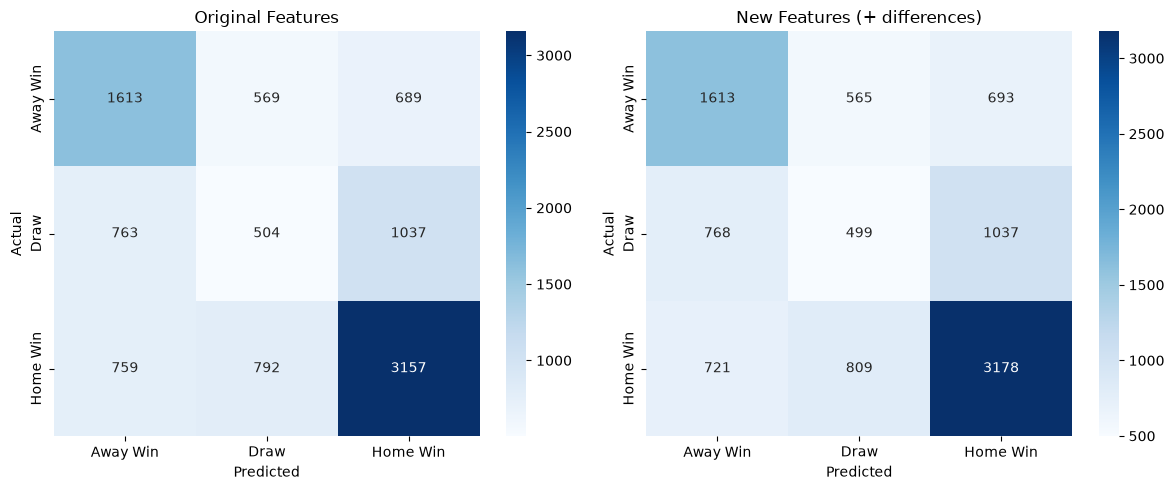

In [21]:
%matplotlib inline

cm_orig = confusion_matrix(y_test, pred_orig)
cm_new = confusion_matrix(y_test, pred_new)

print("Original features confusion matrix:")
print(cm_orig)
print()
print("New features confusion matrix:")
print(cm_new)

labels_cm = ['Away Win', 'Draw', 'Home Win']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=axes[0])
axes[0].set_title('Original Features')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=axes[1])
axes[1].set_title('New Features (+ differences)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [22]:
labels = [0, 1, 2]
class_names = ['Away Win', 'Draw', 'Home Win']

p_orig, r_orig, f_orig, _ = precision_recall_fscore_support(
    y_test, pred_orig, labels=labels, average=None
)
p_new, r_new, f_new, _ = precision_recall_fscore_support(
    y_test, pred_new, labels=labels, average=None
)

comparison = pd.DataFrame({
    'Class': class_names,
    'Original Precision': p_orig,
    'New Precision': p_new,
    'Original Recall': r_orig,
    'New Recall': r_new,
    'Original F1': f_orig,
    'New F1': f_new,
})

comparison.round(3)

,Class,Original Precision,New Precision,Original Recall,New Recall,Original F1,New F1
0,Away Win,0.515,0.520,0.562,0.562,0.537,0.540
1,Draw,0.270,0.266,0.219,0.217,0.242,0.239
2,Home Win,0.647,0.648,0.671,0.675,0.658,0.661


In [23]:
print("Original features macro F1:", round(np.mean(f_orig), 4))
print("New features macro F1:     ", round(np.mean(f_new), 4))

Original features macro F1: 0.4791
New features macro F1:      0.48


In [24]:
# Feature importances of the NEW-features model
for feature, importance in zip(new_features, model_new.feature_importances_):
    print(f"{feature}: {importance:.4f}")

home_elo: 0.1873
away_elo: 0.1897
elo_difference: 0.2123
home_form: 0.0688
away_form: 0.0692
neutral_encoded: 0.0135
abs_elo_difference: 0.1806
form_difference: 0.0785


# Summary - Did the Difference Features Help?

| Metric | Original Features | + Difference Features |
|--------|-------------------|------------------------|
| Accuracy | 53.36% | 53.53% |
| Away Win recall | 0.562 | 0.562 |
| **Draw recall** | **0.219** | **0.217** |
| **Draw F1** | **0.242** | **0.239** |
| Home Win recall | 0.671 | 0.675 |
| Macro-F1 | 0.479 | 0.480 |

### Did the new features improve the model?

**No meaningful improvement.** Accuracy and macro-F1 barely moved (+0.2% and +0.001).
Draw recall and draw F1 were essentially unchanged (and in fact a hair lower). The
difference features did **not** fix our draw problem.

### Which new feature was most useful?

**`abs_elo_difference`** had the highest importance (about 0.18) - almost as important as a
single Elo rating (home_elo ~0.19, away_elo ~0.19). `form_difference` (~0.08) was slightly
more important than each individual form feature. So the model found the new features
informative - but not informative *for draws*.

### Why didn't a high-importance feature help draw prediction?

The model clearly uses `abs_elo_difference` to split on the strength gap - but mostly to
choose a more confident **winner**, not to choose a **draw**. Football is noisy and draws
sit right between two close outcomes, so separating a draw from a narrow win is hard.

### Conclusion and next step

Adding difference features did not help. The next most promising direction is to tune the
class weights directly, or to use a probability-based approach (predict the chance of each
outcome) rather than forcing the model to pick a single result.